In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [31]:
import os

print(os.listdir("/kaggle/input/datasets/olistbr/brazilian-ecommerce"))

['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [32]:
from pathlib import Path
import pandas as pd

data_path = Path("/kaggle/input/datasets/olistbr")

for file in data_path.iterdir():
    print(repr(file.name))

'brazilian-ecommerce'


In [33]:
import os
import pandas as pd

folder = "/kaggle/input/datasets/olistbr/brazilian-ecommerce"

files = os.listdir(folder)
print(files)

order_file = [name for name in files if "orders" in name][0]
print("Using file:", order_file)

orders = pd.read_csv(os.path.join(folder, order_file))

print("Shape:", orders.shape)
orders.head()

['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']
Using file: olist_orders_dataset.csv
Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [34]:
# 查看订单表的列名和缺失情况
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [35]:
# 把下单时间转换为日期格式
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# 按月统计订单数
monthly_orders = (
    orders
    .groupby(orders["order_purchase_timestamp"].dt.to_period("M"))
    .size()
    .reset_index(name="order_count")
)

# 转为更适合画图的日期格式
monthly_orders["order_purchase_timestamp"] = (
    monthly_orders["order_purchase_timestamp"].dt.to_timestamp()
)

monthly_orders.head()

,order_purchase_timestamp,order_count
0,2016-09-01,4
1,2016-10-01,324
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780


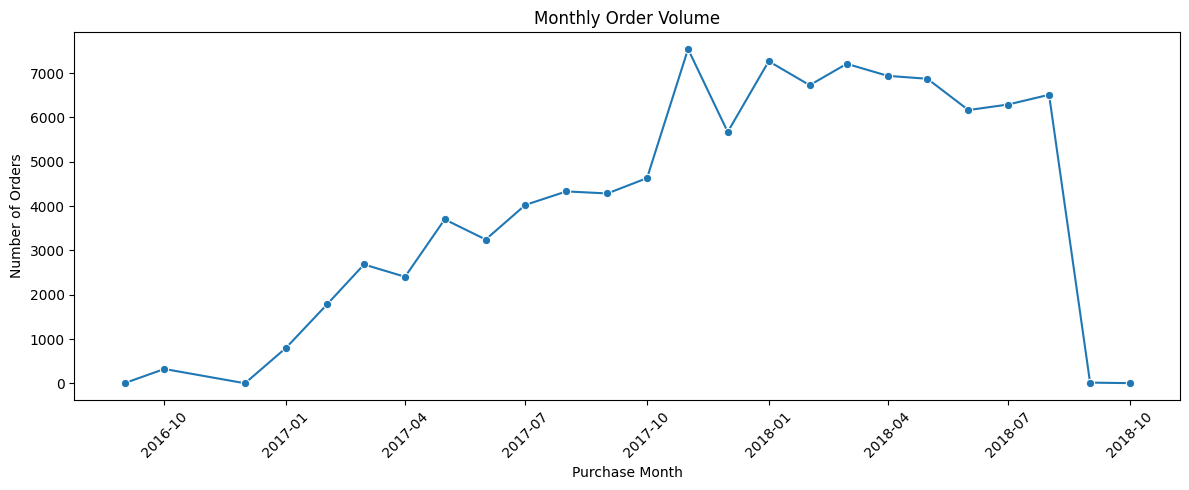

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_purchase_timestamp",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

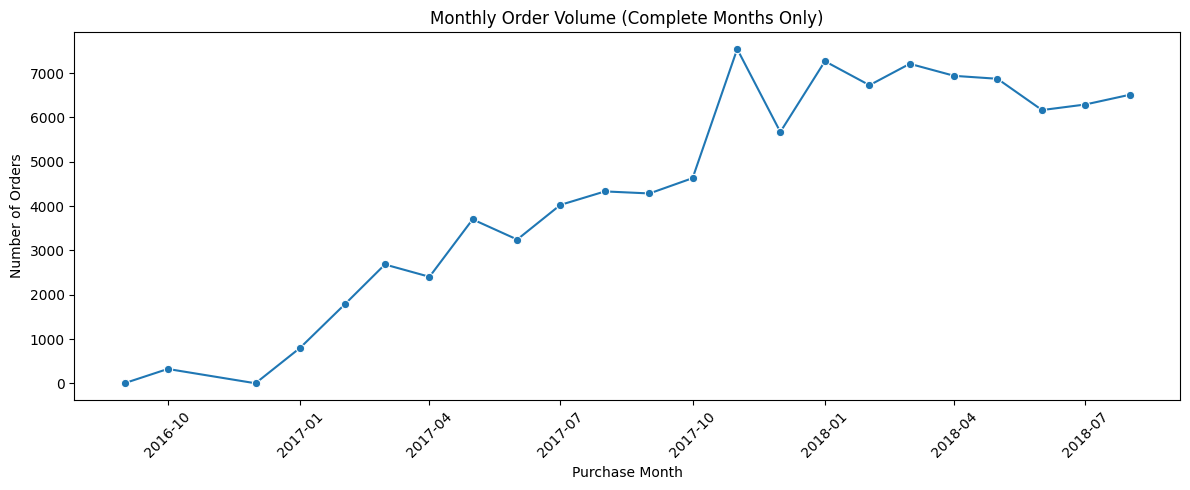

In [37]:
# 数据截止期导致 2018-09 和 2018-10 不完整，因此不用于趋势判断
monthly_orders_clean = monthly_orders[
    monthly_orders["order_purchase_timestamp"] < "2018-09-01"
].copy()

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders_clean,
    x="order_purchase_timestamp",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Volume (Complete Months Only)")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Finding 1: Order growth and stabilization

Order volume grew rapidly throughout 2017 and reached a peak in November 2017.
From January to August 2018, monthly order volume remained relatively stable at
roughly 6,000–7,000 orders. September and October 2018 are excluded because
the dataset is incomplete for those months.

In [38]:
# 读取订单明细表：每一行代表订单中的一个商品
items = pd.read_csv(
    "/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv"
)

# 每笔订单的商品销售额
order_value = (
    items
    .groupby("order_id", as_index=False)
    .agg(gmv=("price", "sum"))
)

# 仅保留已完成配送的订单，并合并订单金额
sales = (
    orders[orders["order_status"] == "delivered"]
    .merge(order_value, on="order_id", how="inner")
)

# 排除不完整月份
sales = sales[
    sales["order_purchase_timestamp"] < "2018-09-01"
].copy()

# 按月汇总 GMV、订单数与平均订单金额
monthly_sales = (
    sales
    .groupby(sales["order_purchase_timestamp"].dt.to_period("M"))
    .agg(
        gmv=("gmv", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales["purchase_month"] = (
    monthly_sales["order_purchase_timestamp"].dt.to_timestamp()
)

monthly_sales["average_order_value"] = (
    monthly_sales["gmv"] / monthly_sales["order_count"]
)

monthly_sales.head()

,order_purchase_timestamp,gmv,order_count,purchase_month,average_order_value
0,2016-09,134.97,1,2016-09-01,134.970000
1,2016-10,40325.11,265,2016-10-01,152.170226
2,2016-12,10.90,1,2016-12-01,10.900000
3,2017-01,111798.36,750,2017-01-01,149.064480
4,2017-02,234223.40,1653,2017-02-01,141.695947


In [39]:
# 读取订单明细表：每一行代表订单中的一个商品
items = pd.read_csv(
    "/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv"
)

# 每笔订单的商品销售额
order_value = (
    items
    .groupby("order_id", as_index=False)
    .agg(gmv=("price", "sum"))
)

# 仅保留已完成配送的订单，并合并订单金额
sales = (
    orders[orders["order_status"] == "delivered"]
    .merge(order_value, on="order_id", how="inner")
)

# 排除不完整月份
sales = sales[
    sales["order_purchase_timestamp"] < "2018-09-01"
].copy()

# 按月汇总 GMV、订单数与平均订单金额
monthly_sales = (
    sales
    .groupby(sales["order_purchase_timestamp"].dt.to_period("M"))
    .agg(
        gmv=("gmv", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales["purchase_month"] = (
    monthly_sales["order_purchase_timestamp"].dt.to_timestamp()
)

monthly_sales["average_order_value"] = (
    monthly_sales["gmv"] / monthly_sales["order_count"]
)

monthly_sales.head()

,order_purchase_timestamp,gmv,order_count,purchase_month,average_order_value
0,2016-09,134.97,1,2016-09-01,134.970000
1,2016-10,40325.11,265,2016-10-01,152.170226
2,2016-12,10.90,1,2016-12-01,10.900000
3,2017-01,111798.36,750,2017-01-01,149.064480
4,2017-02,234223.40,1653,2017-02-01,141.695947


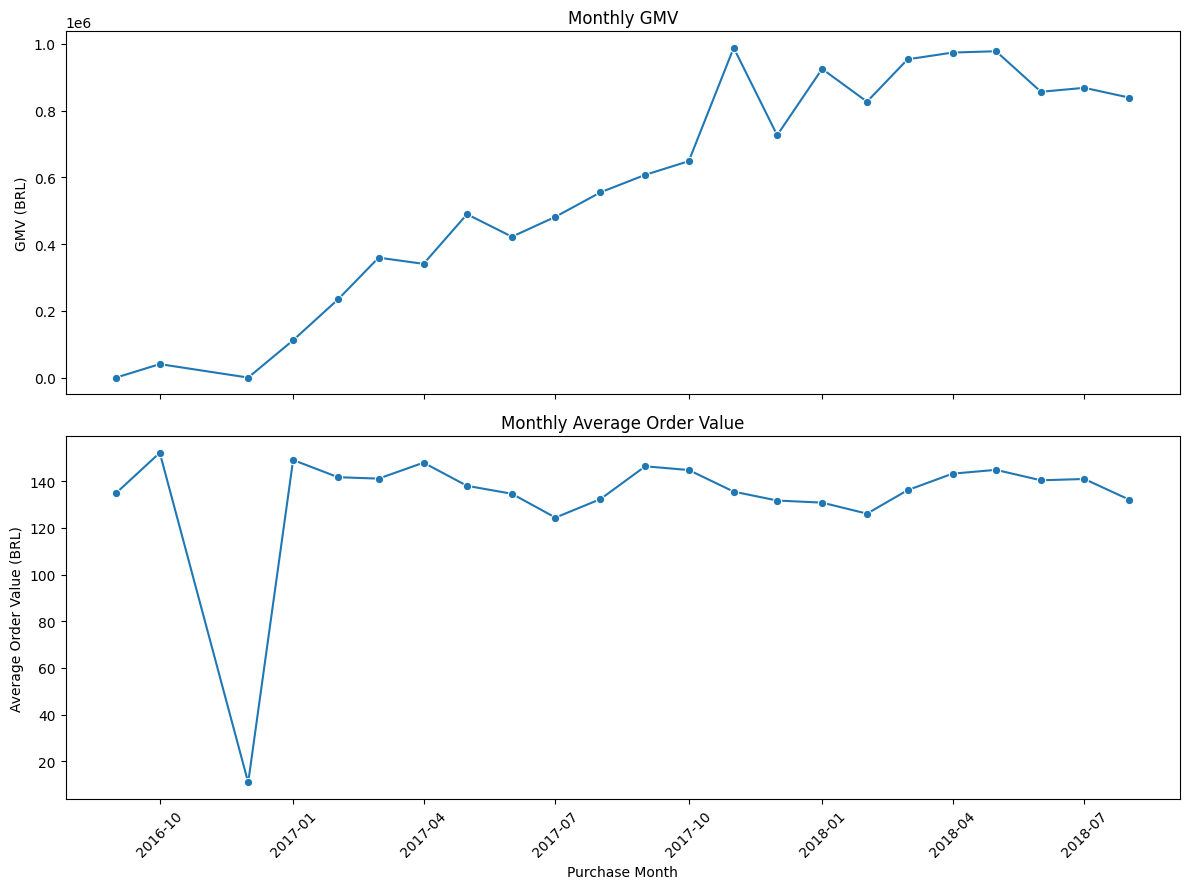

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=monthly_sales,
    x="purchase_month",
    y="gmv",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Monthly GMV")
axes[0].set_xlabel("")
axes[0].set_ylabel("GMV (BRL)")

sns.lineplot(
    data=monthly_sales,
    x="purchase_month",
    y="average_order_value",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Monthly Average Order Value")
axes[1].set_xlabel("Purchase Month")
axes[1].set_ylabel("Average Order Value (BRL)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Finding 2: GMV growth was driven primarily by order volume

Monthly GMV increased rapidly through 2017, peaking at approximately
BRL 1.0 million in November 2017. During 2018, GMV remained broadly stable
at around BRL 0.8–1.0 million per month.

Average order value was relatively stable at approximately BRL 125–150 for
most complete months. This suggests that GMV growth was driven mainly by a
higher number of orders rather than a material increase in spend per order.

The very early months have low order volume and should not be used to infer
average-order-value trends.

In [41]:
# 读取商品信息与品类英文翻译表
products = pd.read_csv(
    "/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_products_dataset.csv"
)

category_translation = pd.read_csv(
    "/kaggle/input/datasets/olistbr/brazilian-ecommerce/product_category_name_translation.csv"
)

# 将已完成订单与订单商品、商品品类连接
category_sales = (
    sales
    .merge(items[["order_id", "product_id", "price"]], on="order_id", how="inner")
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

# 按商品品类计算 GMV 和订单数
top_categories = (
    category_sales
    .groupby("product_category_name_english", as_index=False)
    .agg(
        gmv=("price", "sum"),
        order_count=("order_id", "nunique")
    )
    .sort_values("gmv", ascending=False)
    .head(10)
)

top_categories

,product_category_name_english,gmv,order_count
43,health_beauty,1233131.72,8647
70,watches_gifts,1166176.98,5495
7,bed_bath_table,1023434.76,9272
65,sports_leisure,954852.55,7530
15,computers_accessories,888724.61,6530
39,furniture_decor,711927.69,6307
49,housewares,615628.69,5743
20,cool_stuff,610204.10,3559
5,auto,578966.65,3810
69,toys,471286.48,3804


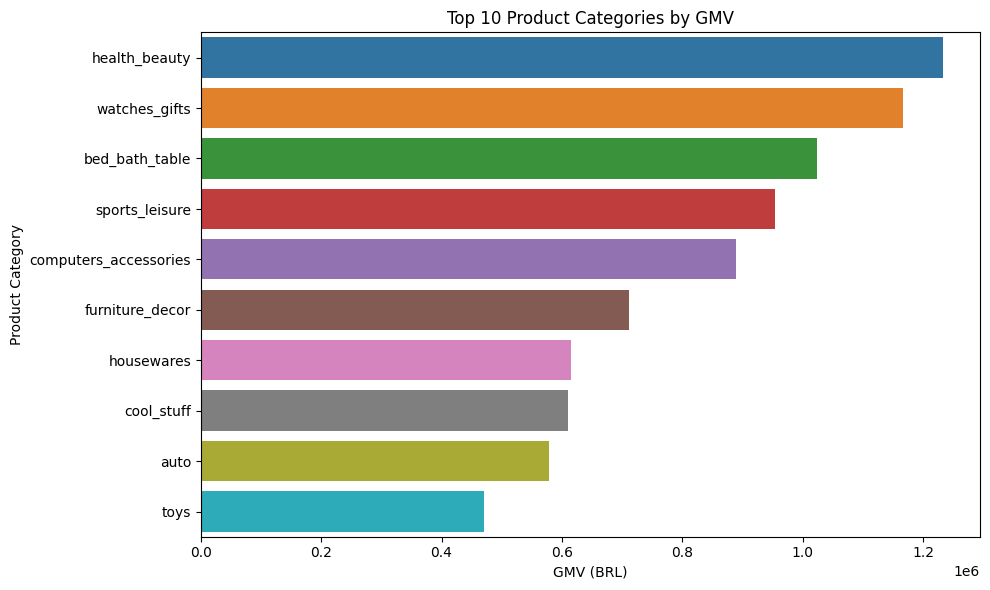

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_categories,
    x="gmv",
    y="product_category_name_english",
    hue="product_category_name_english",
    legend=False
)

plt.title("Top 10 Product Categories by GMV")
plt.xlabel("GMV (BRL)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## Finding 3: A small group of categories drives a large share of GMV

Health & Beauty generated the highest GMV, followed by Watches & Gifts and
Bed, Bath & Table. These categories should be prioritized for inventory
availability, seller support, and targeted marketing because they contribute
the most sales value.

In [43]:
# 读取评价数据
reviews = pd.read_csv(
    "/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv"
)

# 只分析完整月份内、已配送订单
delivery = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_purchase_timestamp"] < "2018-09-01")
].copy()

# 转换配送日期
delivery["order_delivered_customer_date"] = pd.to_datetime(
    delivery["order_delivered_customer_date"]
)

delivery["order_estimated_delivery_date"] = pd.to_datetime(
    delivery["order_estimated_delivery_date"]
)

# 计算配送耗时和是否晚于承诺日期
delivery["delivery_days"] = (
    delivery["order_delivered_customer_date"]
    - delivery["order_purchase_timestamp"]
).dt.days

delivery["is_late"] = (
    delivery["order_delivered_customer_date"]
    > delivery["order_estimated_delivery_date"]
)

# 每笔订单保留一个平均评分
review_by_order = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

# 合并配送与评分
delivery_reviews = delivery.merge(
    review_by_order,
    on="order_id",
    how="inner"
)

# 比较准时和延迟订单
late_review_summary = (
    delivery_reviews
    .groupby("is_late", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        average_delivery_days=("delivery_days", "mean")
    )
)

late_review_summary

,is_late,order_count,average_review_score,average_delivery_days
0,False,88171,4.294311,10.412860
1,True,7661,2.566506,30.918679


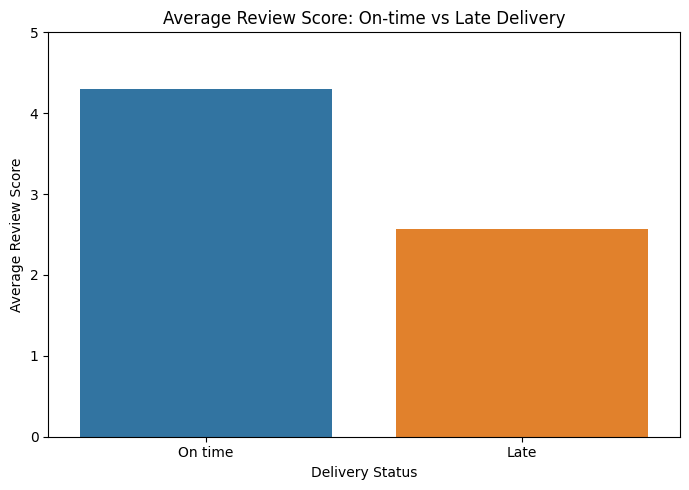

In [44]:
late_review_summary["delivery_status"] = late_review_summary["is_late"].map({
    False: "On time",
    True: "Late"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=late_review_summary,
    x="delivery_status",
    y="average_review_score",
    hue="delivery_status",
    legend=False
)

plt.title("Average Review Score: On-time vs Late Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## Finding 4: Late delivery is strongly associated with lower customer satisfaction

On-time orders received an average review score of approximately 4.3 out of 5,
while late orders received an average score of approximately 2.6.

This is an association rather than proof of causation, but the gap is large
enough to make delivery reliability a clear operational priority.

## Recommendation

Prioritize reducing late deliveries through seller-performance monitoring,
more accurate delivery estimates, and proactive customer communication when
a delay is likely.